In [1]:
# First physical cell: standard-library integrity checks before teaching imports.
from pathlib import Path
import hashlib, json
BASE = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data_integrity.json').is_file() and (p / 'experiment.py').is_file()), None)
if BASE is None:
    raise ValueError('Run within the complete ML047 directory or its outputs subdirectory')
EXPECTED = {'data/protocol.json': 'ac41c663df03f05c32be53289515862ad804464a3331b9e58ee4027fcf929664', 'data/classification.csv': '7e8ff3c2066f3b042cc24af9f8ba1b419d9b1857cf7a9709761d9d3df031e8de', 'data/regression_train.csv': '06f0317280c0948abe464bdf81b863aa8780ea7e3175a3d11dc15f36c925eaff', 'data/regression_calibration.csv': 'c1d7f458a9a3e80e7287b34455bcfb19cfdcc56078219611ef1283465efa74b1', 'data/regression_evaluation.csv': 'c25a4306db3cdfefd1d000942c8eb01b2987b858b6e70efc109e438d98ba7ae8', 'data_integrity.json': 'b733cb8f80bc21ef31e58043ff7dcbb5666e46e6e2220f4e7508bff8be6d10e3', 'numeric.py': '3e687aa0dea0a5aeeb683d198cd25d7aae6915d09b9234faf2cf5a086b50b74d', 'protocol.py': '878eb780d0173e715e50dbcf83dae86e361f46e994f2a0b5112b4f777ccf1f74', 'calibration.py': '0020918e73c89820454b60e15ff6d4095b4fc85acb7e52291831a7bf48d6fa59', 'conformal.py': 'b29a127d8d16a25acfd398ee6eb171d6ff60d02c3de5ace297fd8f8516f39c56', 'generate_data.py': '12e68d7837177850771e314d4e4156f84db7d4acc6a9bd18f88908ed829964a9', 'experiment.py': '65be52d917e0fb7b82c445348b02a8fbbf3da4e251687c0639f0c39db1b3a979', 'audit.py': '879b3523d955654cb72965ecb30b0858a09e3c7ed2eb0401aaa9f379fd2437b4', 'plots.py': '5460ef5dc372aee0ec87753252f05e83808c30cca1cc5f37151181875f8fa2e2', 'requirements.txt': '3fb2ffac7da882b9bf919c5b5517c61623d0f25ac090efefc5e11eb49d68fffb', 'environment.yml': 'f79067b55db3bba4a1e6beee798d2c7e9ece48e186f9aff9b967d5ada95c50d5'}
for relative, wanted in EXPECTED.items():
    if hashlib.sha256((BASE / relative).read_bytes()).hexdigest() != wanted:
        raise ValueError('Teaching contract changed: ' + relative)
print('All', len(EXPECTED), 'data, code, and environment contracts verified.')

All 16 data, code, and environment contracts verified.


# 第047讲 校准与预测不确定性

两个独立实验：固定分类分数的温度校准，以及独立残差构造的回归预测区间。最高置信度ECE和正类ECE分开计算。全部为合成数据，不声称训练网络或现实部署效果。

initial_metrics Brier 0.21000000000000002 accuracy 0.75 positive ECE 0.25000000000000006 top ECE 0.15000000000000002
optimum_metrics Brier 0.1875 accuracy 0.75 positive ECE 0.25000000000000006 top ECE 1.4988010832439613e-12


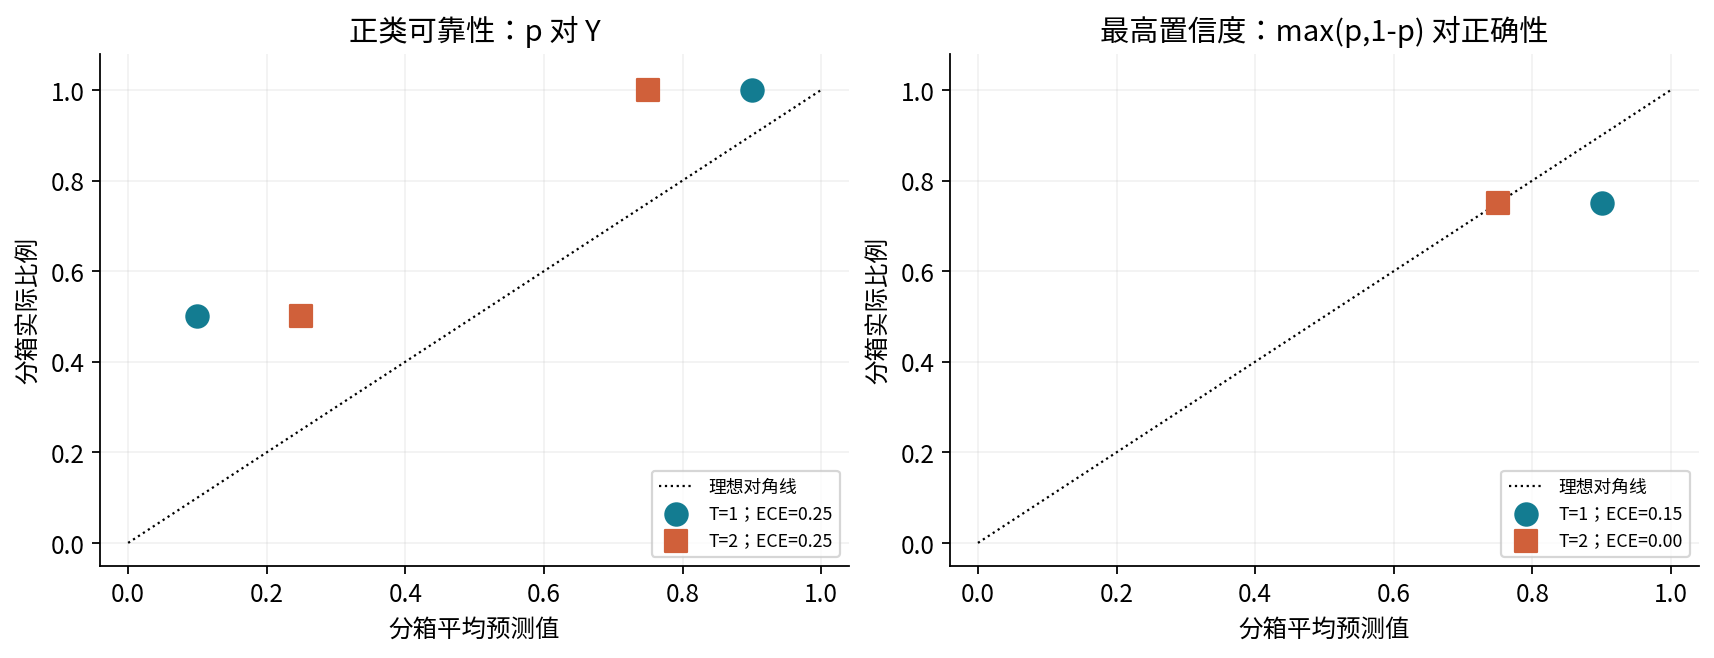

In [2]:
import os, sys, io, math
sys.path.insert(0, str(BASE))
os.environ.setdefault('MPLCONFIGDIR', str(BASE / 'outputs/mpl'))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import experiment as e
import calibration as cb
import conformal as cf
import plots
from numeric import canonical_bytes, safe_write
classification, regression, cfg = e.load_inputs()
report = e.main_report(classification, regression, cfg)
def show(i):
    fig = plots.figure(i, report)
    stream = io.BytesIO()
    fig.savefig(stream, format='png', dpi=160, bbox_inches='tight')
    display(Image(data=stream.getvalue(), format='png'))
    plt.close(fig)
for name in ['initial_metrics', 'optimum_metrics']:
    value = report['hand'][name]
    print(name, 'Brier', value['binary_Brier'], 'accuracy', value['accuracy'],
          'positive ECE', value['positive_class_reliability']['ece'],
          'top ECE', value['top_label_reliability']['ece'])
show(1)

## 同一四行：三次前向、两次同步更新
每行显示损失、局部导数、平均梯度和Hessian贡献。第1行损失上升并不阻止平均损失下降。

STAGE 0 a= 1.0 T= 1.0
{"gradient_contribution": -0.054930614433405474, "hessian_contribution": 0.10862540647313236, "local_dloss_dp": 1.1111111111111112, "local_dp_dscaled_logit": 0.08999999999999997, "local_dscaled_logit_da": -2.1972245773362196, "loss": 0.10536051565782628, "mean_loss_contribution": 0.02634012891445657, "probability": 0.09999999999999998, "raw_logit": -2.1972245773362196, "row": 1, "scaled_logit": -2.1972245773362196, "stable_dloss_dscaled_logit": 0.09999999999999998, "y": 0}
{"gradient_contribution": 0.49437552990064937, "hessian_contribution": 0.10862540647313236, "local_dloss_dp": -10.000000000000002, "local_dp_dscaled_logit": 0.08999999999999997, "local_dscaled_logit_da": -2.1972245773362196, "loss": 2.302585092994046, "mean_loss_contribution": 0.5756462732485115, "probability": 0.09999999999999998, "raw_logit": -2.1972245773362196, "row": 2, "scaled_logit": -2.1972245773362196, "stable_dloss_dscaled_logit": -0.8999999999999999, "y": 1}
{"gradient_contribution": 

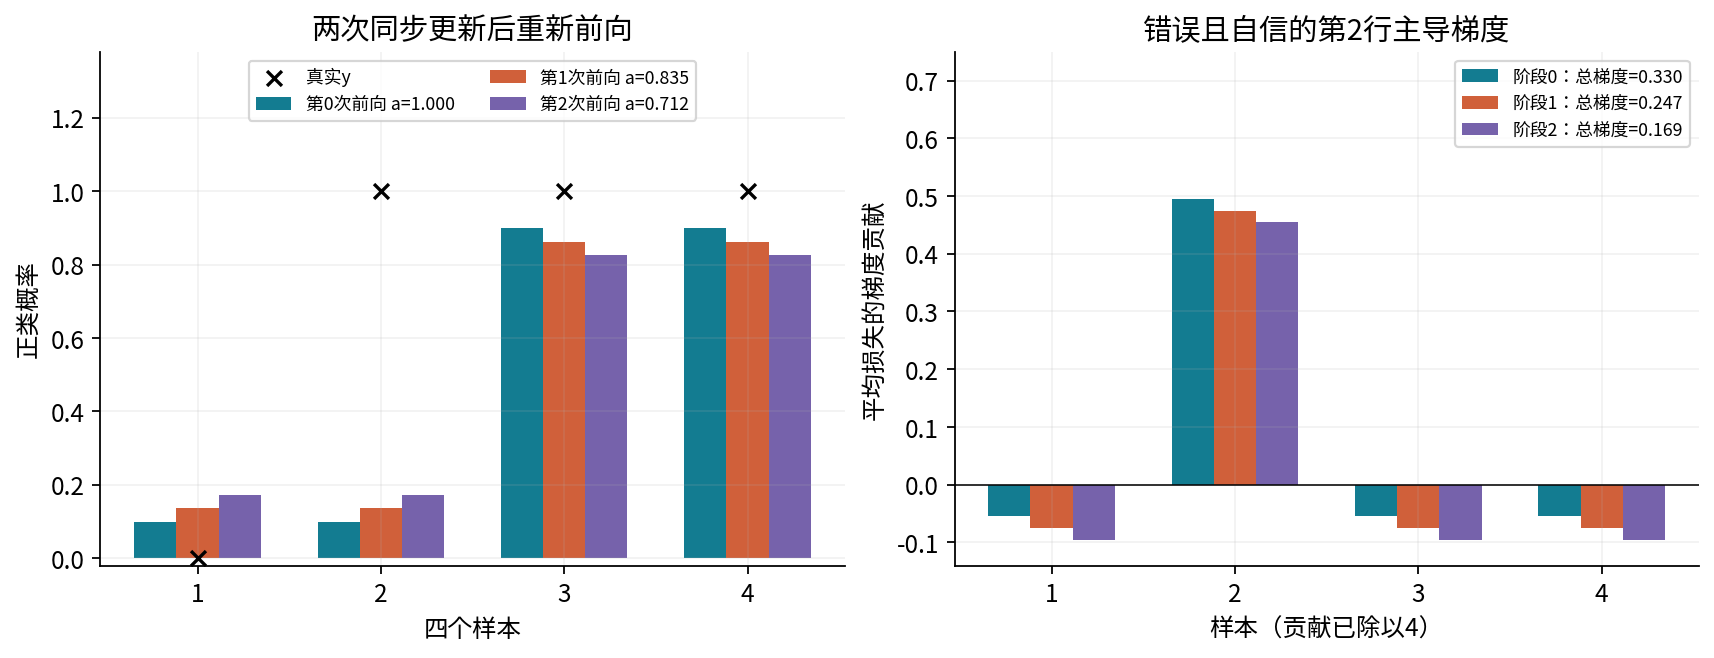

In [3]:
for state in report['hand']['states']:
    print('STAGE', state['stage'], 'a=', state['inverse_temperature'], 'T=', state['temperature'])
    for row in state['rows']:
        print(json.dumps(row, sort_keys=True))
    print('Mean loss, gradient, Hessian:', state['mean_log_loss'], state['gradient'], state['hessian'])
    if state['stage'] < 2:
        print('Synchronous next a:', state['inverse_temperature'] - .5*state['gradient'])
show(2)

Independent analytic certificate: {'inverse_temperature': 0.5, 'temperature': 2.0, 'positive_probabilities': [0.25, 0.25, 0.75, 0.75], 'binary_Brier': 0.1875, 'positive_class_ECE': 0.25, 'top_label_ECE': 0.0, 'accuracy': 0.75, 'scope': 'declared symmetric four-logit example only'}
Numerical optimum: {'status': 'bracket_tolerance', 'bounds': [0.0, 4.0], 'final': {'inverse_temperature': 0.500000000003638, 'temperature': 1.999999999985448, 'infinite_temperature': False, 'mean_log_loss': 0.5623351446188084, 'gradient': 3.2931990467943706e-12, 'hessian': 0.9052117206058186, 'probabilities': [0.2499999999985012, 0.2499999999985012, 0.7500000000014987, 0.7500000000014987]}, 'projected_gradient_residual': 3.2931990467943706e-12, 'iterations': 39, 'selection_scope': 'only supplied calibration logits and labels; no evaluation labels accepted'}
p, expected Brier: 0.1 0.61
p, expected Brier: 0.25 0.4375
p, expected Brier: 0.5 0.25
p, expected Brier: 0.75 0.1875
p, expected Brier: 0.9 0.21000000000

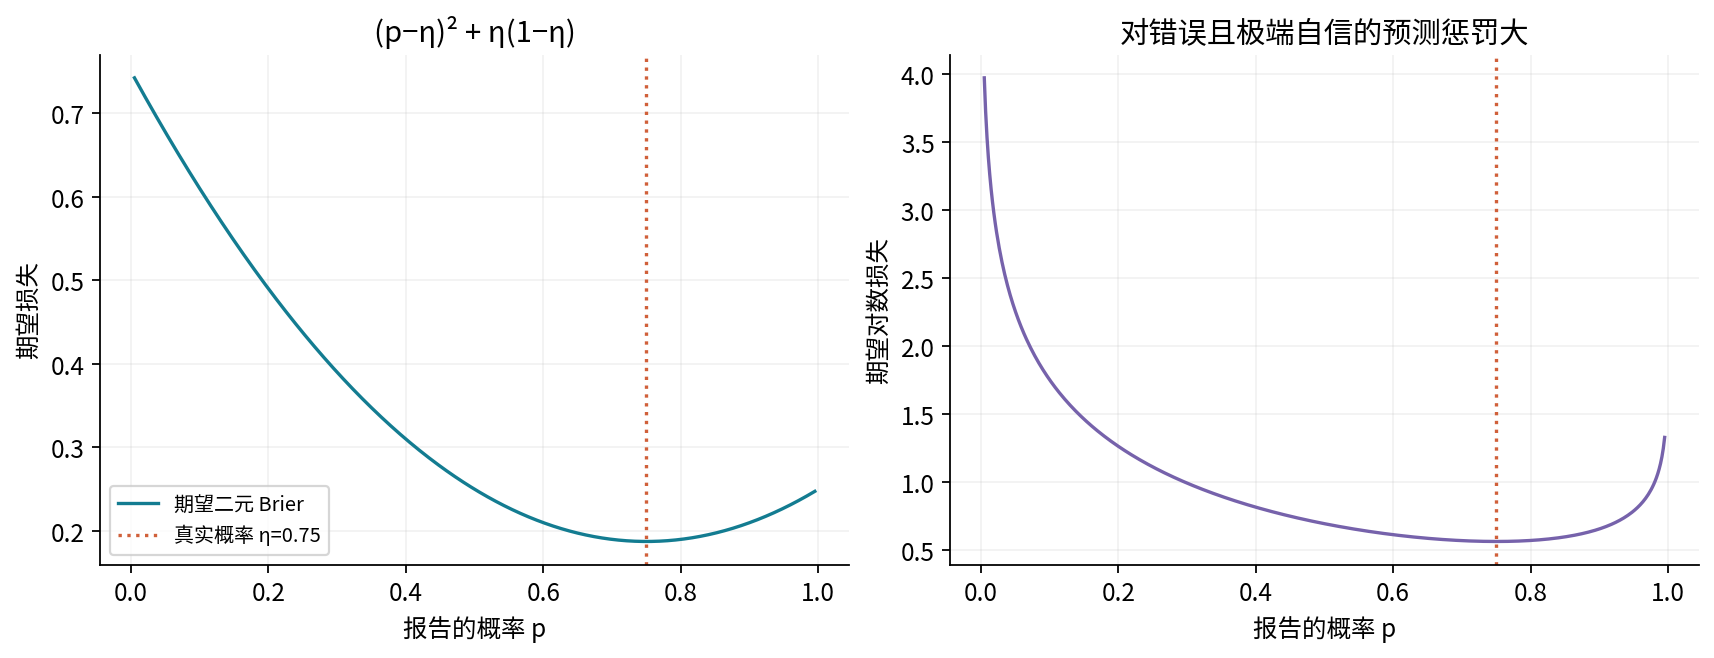

In [4]:
from decimal import Decimal, localcontext
analytic = report['hand']['analytic_certificate']
print('Independent analytic certificate:', analytic)
print('Numerical optimum:', {k:v for k,v in report['hand']['fitted'].items() if k != 'bracket_trace'})
eta = .75
for p in [.1, .25, .5, .75, .9]:
    direct = eta*(p-1)**2 + (1-eta)*p**2
    decomposed = (p-eta)**2 + eta*(1-eta)
    if not math.isclose(direct, decomposed, abs_tol=1e-15):
        raise RuntimeError('Brier expectation decomposition failed')
    print('p, expected Brier:', p, direct)
show(3)

## 只用400行校准选择，4000行评价不反馈
选择记录在计算评价指标前冻结。oracle列不进入温度拟合。

Status, bounds, iterations: bracket_tolerance [0.0, 4.0] 39
Chosen a,T,NLL: 0.5081159501824004 1.9680547316828492 0.5699223239854363
Projected gradient residual: 2.2158729625493255e-12
Choice SHA256: 45c003c0094ede5cf8b821fd44ea97c8811ccbe6ae58ee58f994e4efb5f08ca0
Independent SciPy scalar fit: {'success': True, 'message': 'Solution found.', 'inverse_temperature': 0.5081159352140575, 'objective': 0.5699223239854363, 'function_evaluations': 14}
First and last bisection records: [{'iteration': 0, 'lo': 0.0, 'hi': 4.0, 'a': 2.0, 'gradient': 0.33327610805403757, 'loss': 0.9164232029926492}, {'iteration': 1, 'lo': 0.0, 'hi': 2.0, 'a': 1.0, 'gradient': 0.20942234631760392, 'loss': 0.6298141830433763}] [{'iteration': 37, 'lo': 0.5081159501569346, 'hi': 0.5081159501860384, 'a': 0.5081159501714865, 'gradient': -5.163492185905616e-12, 'loss': 0.5699223239854363}, {'iteration': 38, 'lo': 0.5081159501714865, 'hi': 0.5081159501860384, 'a': 0.5081159501787624, 'gradient': -2.439150162229786e-13, 'los

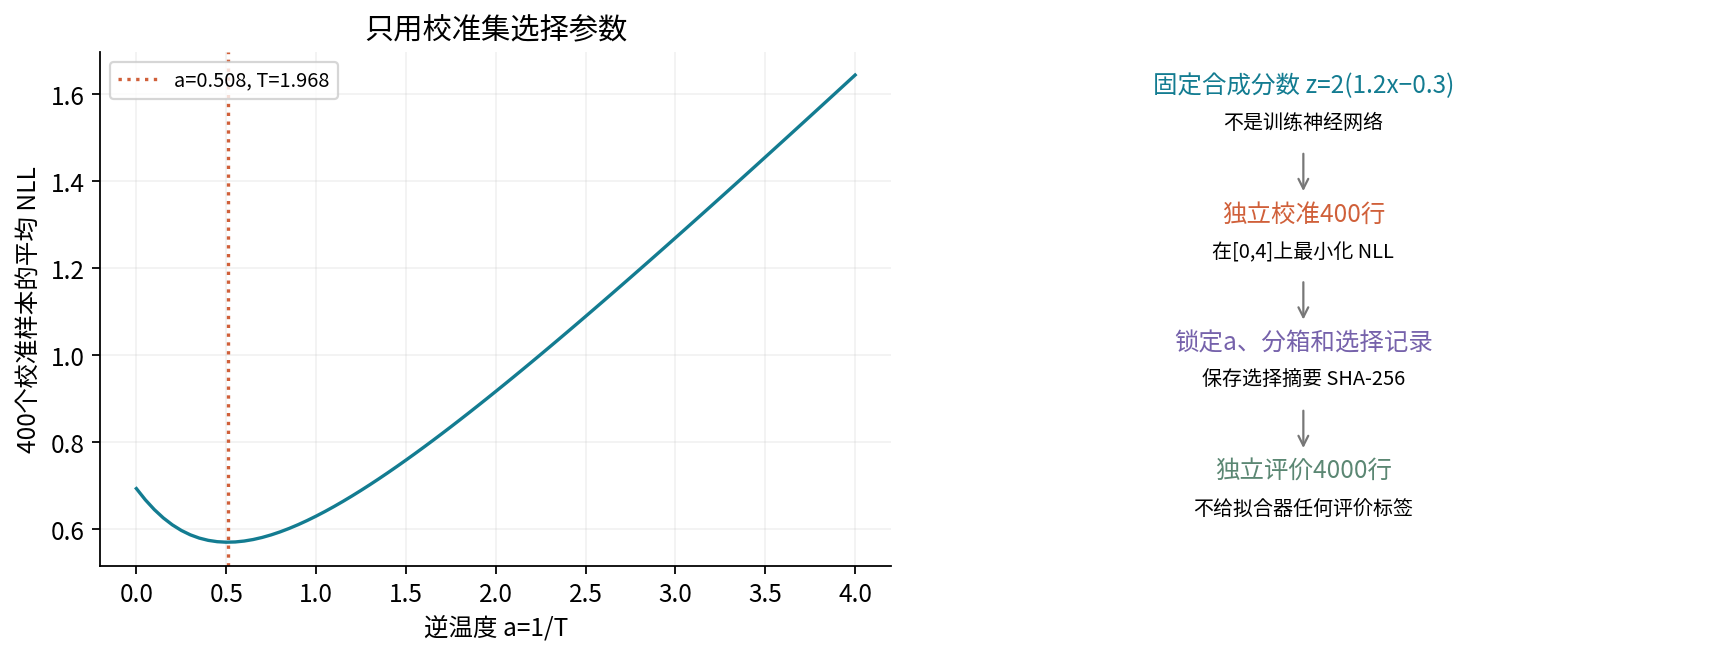

In [5]:
temp = report['temperature']
fit = temp['frozen_choice']['fit']
print('Status, bounds, iterations:', fit['status'], fit['bounds'], fit['iterations'])
print('Chosen a,T,NLL:', fit['final']['inverse_temperature'], fit['final']['temperature'], fit['final']['mean_log_loss'])
print('Projected gradient residual:', fit['projected_gradient_residual'])
print('Choice SHA256:', temp['choice_sha256'])
print('Independent SciPy scalar fit:', temp['scipy_reference'])
print('First and last bisection records:', fit['bracket_trace'][:2], fit['bracket_trace'][-2:])
show(4)

calibration before {'n': 400, 'mean_log_loss': 0.6298141830433763, 'binary_Brier': 0.20869347282396633, 'accuracy': 0.68, 'library_binary_Brier': 0.20869347282396633, 'library_log_loss': 0.6298141830433763}
Positive-class bins: {'bins': [{'bin': 0, 'lower': 0.0, 'upper': 0.2, 'upper_inclusive': False, 'count': 141, 'mean_score': 0.07641652887564022, 'empirical_outcome_rate': 0.19148936170212766, 'weighted_absolute_gap': 0.04056317357133682}, {'bin': 1, 'lower': 0.2, 'upper': 0.4, 'upper_inclusive': False, 'count': 87, 'mean_score': 0.2935189770812991, 'empirical_outcome_rate': 0.47126436781609193, 'weighted_absolute_gap': 0.03865962248481744}, {'bin': 2, 'lower': 0.4, 'upper': 0.6000000000000001, 'upper_inclusive': False, 'count': 43, 'mean_score': 0.5008834796430427, 'empirical_outcome_rate': 0.4418604651162791, 'weighted_absolute_gap': 0.006344974061627089}, {'bin': 3, 'lower': 0.6000000000000001, 'upper': 0.8, 'upper_inclusive': False, 'count': 55, 'mean_score': 0.7121570785753812, 

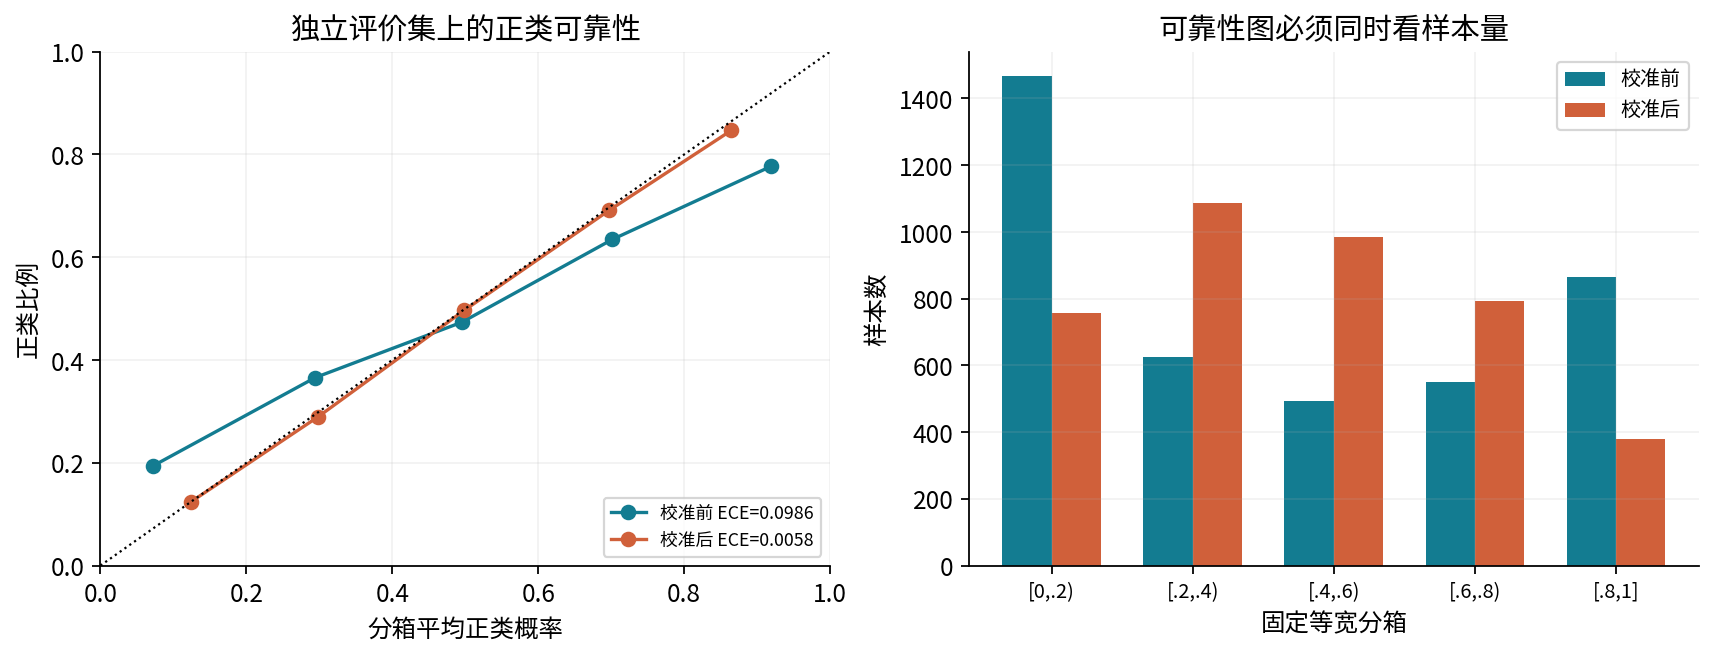

Evaluation-label mutation leaves choice exactly unchanged.


In [6]:
for role, stages in temp['metrics'].items():
    for timing, values in stages.items():
        print(role, timing, {k:values[k] for k in ['n','mean_log_loss','binary_Brier','accuracy','library_binary_Brier','library_log_loss']})
        print('Positive-class bins:', values['positive_class_reliability'])
        print('Top-label bins:', values['top_label_reliability'])
show(5)
import copy
changed = copy.deepcopy(classification)
changed['evaluation']['y'] = 1 - changed['evaluation']['y']
changed['evaluation']['true_probability'] = 1 - changed['evaluation']['true_probability']
changed_result = e.temperature_report(changed, cfg)
if canonical_bytes(changed_result['frozen_choice']) != canonical_bytes(temp['frozen_choice']):
    raise RuntimeError('Evaluation information changed selection')
print('Evaluation-label mutation leaves choice exactly unchanged.')

## 新回归实验：60训练、99校准、400评价
重复训练的预测方差不是所有认知不确定性的总和；区间目标是新的响应Y，不只是条件均值。

Training fit: {'theta': [1.0026966836620277, 0.4597162327926178], 'rank': 2, 'singular_values': [8.97199508686908, 7.002583712580322], 'condition_number': 1.2812406756024437, 'training_mse': 0.2076923637933965}
Noise mechanism: {'regression_noise_intercept': 0.2, 'regression_noise_abs_slope': 0.3, 'regression_noise_shift_factor': 2.5}
x, noise variance, training-prediction variance: -2.0 0.6400000000000001 0.023067815203639083
x, noise variance, training-prediction variance: 0.0 0.04000000000000001 0.003436420864401716
x, noise variance, training-prediction variance: 2.0 0.6400000000000001 0.02230745276898735
Scope: sampling variability of this correctly specified line estimator; not a complete Bayesian posterior or all model misspecification uncertainty


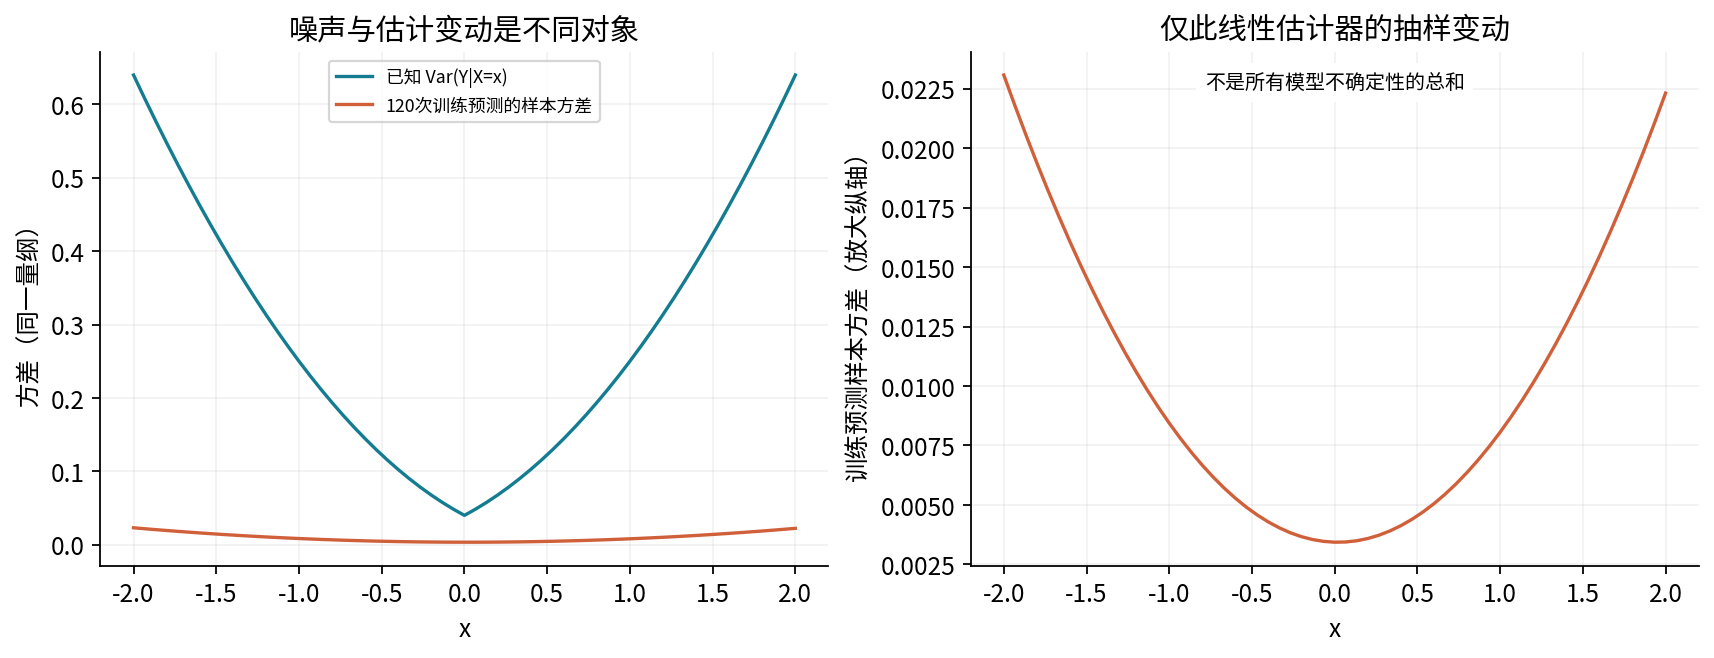

In [7]:
main = report['conformal']['main']
print('Training fit:', main['fit'])
print('Noise mechanism:', {k:cfg[k] for k in cfg if k.startswith('regression_noise')})
u = report['conformal']['uncertainty_components']
for i in [0,30,60]:
    print('x, noise variance, training-prediction variance:', u['x'][i], u['known_conditional_noise_variance'][i], u['repeated_training_prediction_variance_ddof1'][i])
print('Scope:', u['scope'])
show(6)

Calibration row: 1 x= 1.3350352733183102 y= 1.4964286335785988 prediction= 1.616434070157184 abs residual= 0.1200054365785852
Calibration row: 2 x= -1.940013943476632 y= -0.8079664145566423 prediction= 0.11084078200179992 abs residual= 0.9188071965584422
Calibration row: 3 x= -0.37815735522217464 y= 1.063026816149831 prediction= 0.8288516089164698 abs residual= 0.23417520723336127
Calibration row: 4 x= -0.5019481963378061 y= 1.105419742332998 prediction= 0.7719429497845622 abs residual= 0.33347679254843565
Calibration row: 5 x= -0.1570974927848674 y= 0.9470407687477894 prediction= 0.930476416097803 abs residual= 0.016564352649986458
Calibration row: 6 x= -0.9707993347376362 y= 0.3050359035442678 prediction= 0.556404470698862 abs residual= 0.2513685671545942
Calibration row: 7 x= 0.48142744858017883 y= 1.5341282316324227 prediction= 1.2240166966862693 abs residual= 0.3101115349461534
Calibration row: 8 x= 1.865685867992449 y= 1.5488471473873846 prediction= 1.8603827624699416 abs residua

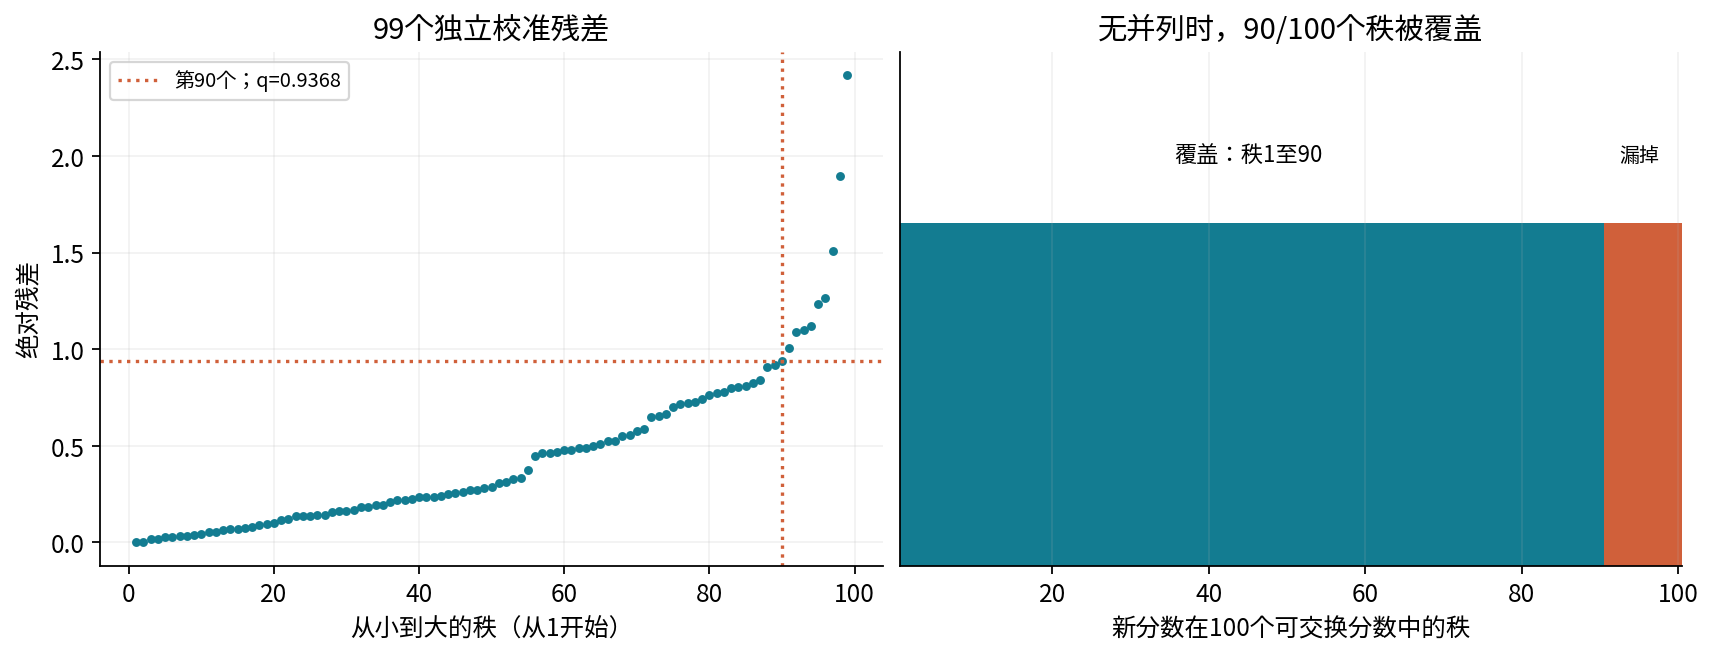

In [8]:
for i, (x,y,pred,score) in enumerate(zip(regression['calibration']['x'], regression['calibration']['y'], main['calibration_prediction'], main['calibration_scores']),1):
    print('Calibration row:', i, 'x=', float(x), 'y=', float(y), 'prediction=', pred, 'abs residual=', score)
print('Finite-sample quantile:', main['quantile'])
ordered = sorted(main['calibration_scores'])
print('Sorted values at ranks 89,90,91:', ordered[88:91])
show(7)

Evaluation row: 1 x= 0.8436671232171316 prediction= 1.3905441552783926 interval= [0.4537519557804224, 2.327336354776363] Y= 0.8898567173118178 covered= True shifted Y= -0.034658617615873855 shift covered= False
Evaluation row: 2 x= -0.6043773338343885 prediction= 0.7248546125664362 interval= [-0.21193758693153397, 1.6616468120644066] Y= 0.6550219596882585 covered= True shifted Y= 0.6814944996715959 shift covered= True
Evaluation row: 3 x= -0.2282694611278342 prediction= 0.8977575069307389 interval= [-0.039034692567231355, 1.834549706428709] Y= 0.6830266817897765 covered= True shifted Y= 0.4130092194894922 shift covered= True
Evaluation row: 4 x= -0.22821686200161118 prediction= 0.8977816876028942 interval= [-0.03901051189507598, 1.8345738871008646] Y= 0.6997060308368876 covered= True shifted Y= 0.45466025289366907 shift covered= True
Evaluation row: 5 x= -1.7254314795011436 prediction= 0.20948782396396903 interval= [-0.7273043755340012, 1.1462800234619392] Y= -0.8822927880441116 covere

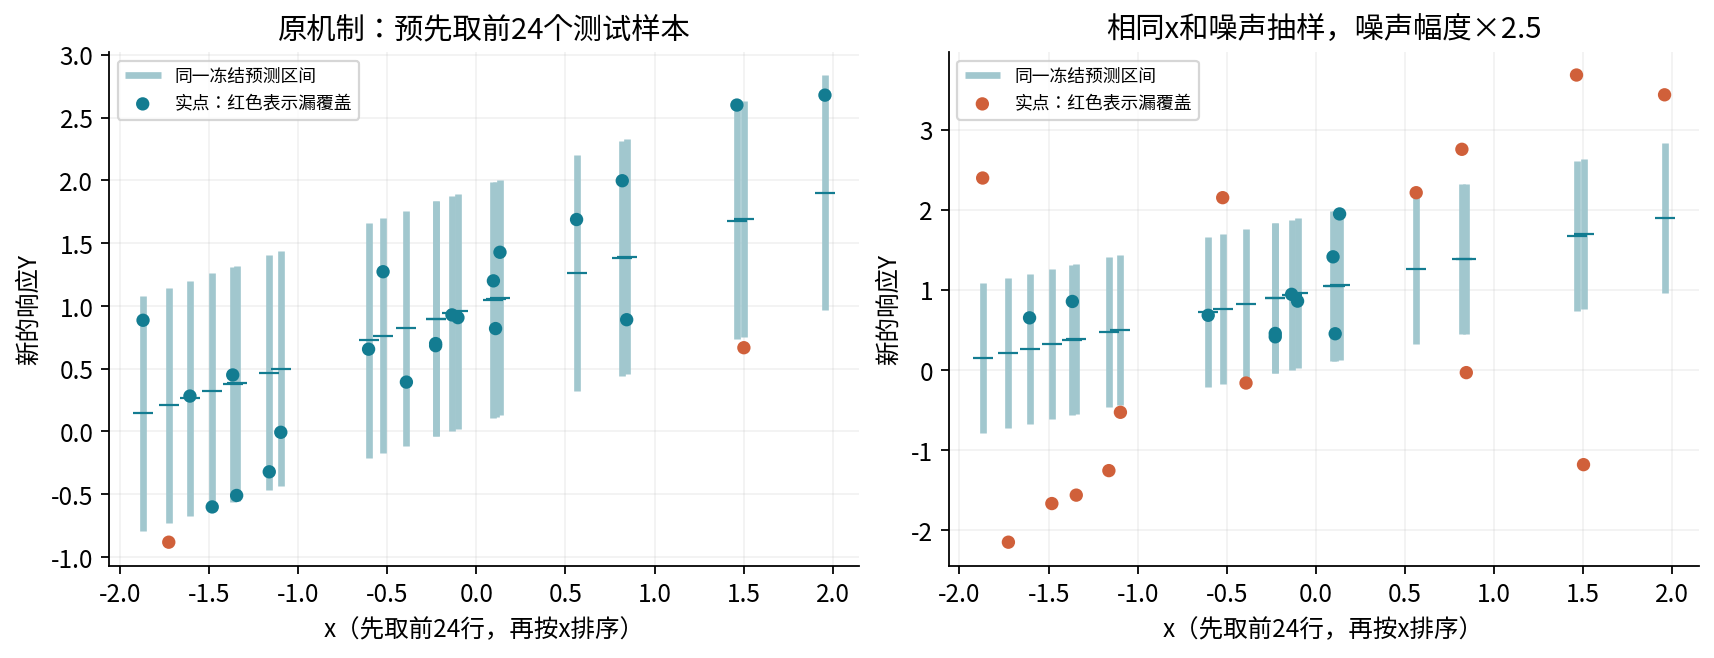

In [9]:
for i in range(cfg['interval_display_count']):
    print('Evaluation row:', i+1, 'x=', float(regression['evaluation']['x'][i]),
          'prediction=', main['test_prediction'][i],
          'interval=', [main['baseline']['interval_lower'][i], main['baseline']['interval_upper'][i]],
          'Y=', float(regression['evaluation']['y'][i]), 'covered=', main['baseline']['covered'][i],
          'shifted Y=', float(regression['evaluation']['shifted_y'][i]), 'shift covered=', main['noise_shift']['covered'][i])
print('All 400 baseline / shifted coverages:', main['baseline']['coverage'], main['noise_shift']['coverage'])
print('Groups:', main['groups'])
show(8)

## 保留整体、分组与噪声改变结果
120次重复的独立单位是整套训练/校准/评价实验；±2 MCSE仅是数值实验均值的近似误差描述。

{"coverage": 0.84, "groups": {"high_abs_x": {"coverage": 0.7448979591836735, "n": 196, "shifted_coverage": 0.30612244897959184}, "low_abs_x": {"coverage": 0.9313725490196079, "n": 204, "shifted_coverage": 0.5637254901960784}}, "infinite": false, "invalid_reuse_coverage": 0.0, "quantile": 0.7079228091817972, "rank": 90, "repetition": 0, "shifted_coverage": 0.4375, "theta": [1.0544627815992356, 0.6302599004494613], "width": 1.4158456183635943}
{"coverage": 0.87, "groups": {"high_abs_x": {"coverage": 0.7548076923076923, "n": 208, "shifted_coverage": 0.3701923076923077}, "low_abs_x": {"coverage": 0.9947916666666666, "n": 192, "shifted_coverage": 0.6770833333333334}}, "infinite": false, "invalid_reuse_coverage": 0.0, "quantile": 0.8523236221863923, "rank": 90, "repetition": 1, "shifted_coverage": 0.5175, "theta": [0.9706864229866414, 0.5948822837889362], "width": 1.7046472443727847}
{"coverage": 0.8925, "groups": {"high_abs_x": {"coverage": 0.8181818181818182, "n": 209, "shifted_coverage": 

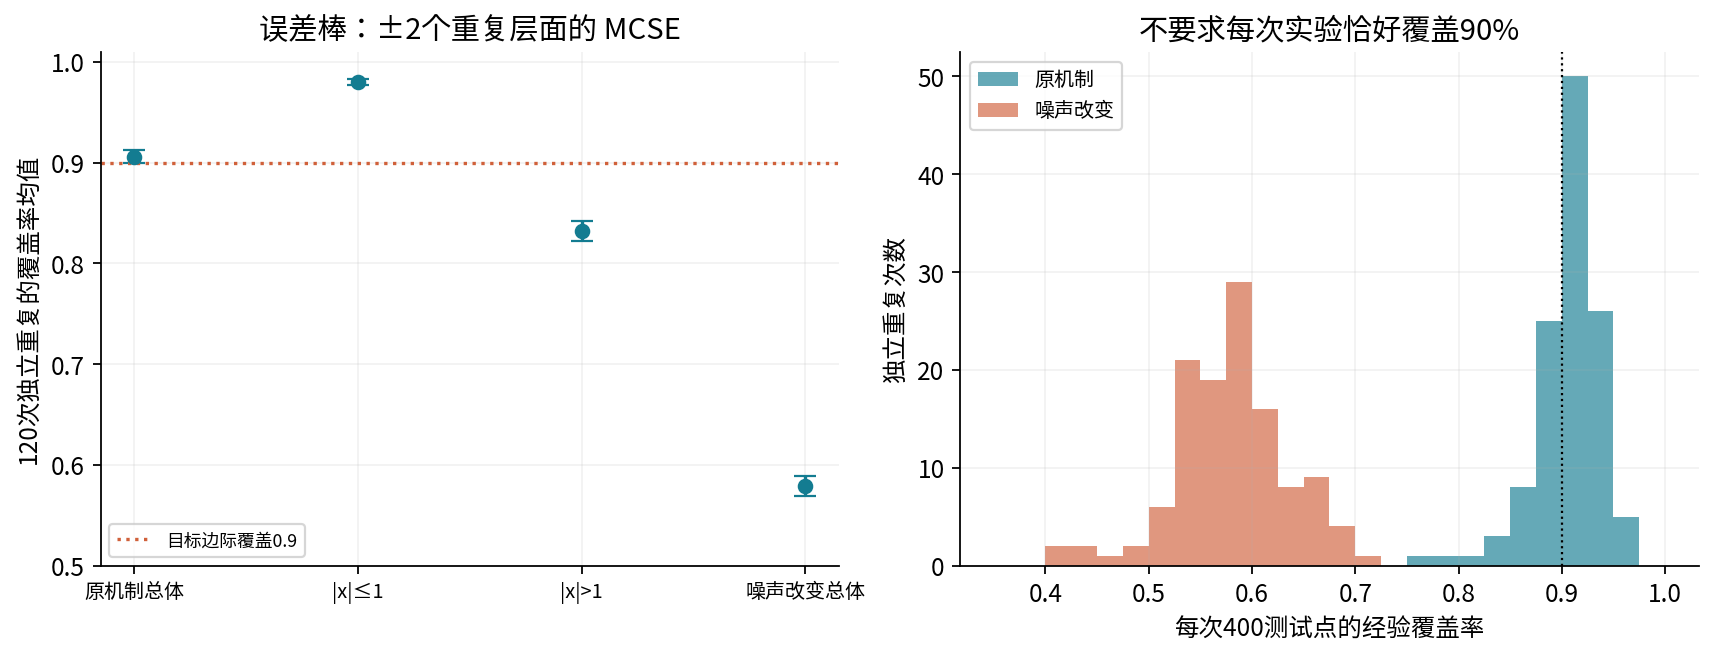

In [10]:
for row in report['conformal']['repetitions']:
    print(json.dumps(row, sort_keys=True))
print('Summary:', json.dumps(report['conformal']['summary'], sort_keys=True))
print('MC scope:', report['conformal']['mc_scope'])
show(9)

Nine calibration scores: {'n_calibration': 9, 'miscoverage': 0.1, 'nominal_alpha_fraction': '1/10', 'rank': 9, 'quantile': 9.0, 'infinite': False, 'quantile_definition': 'k-th order statistic, k=ceil((n+1)*(1-alpha)); infinity if k>n; no interpolation', 'nominal_alpha_semantics': 'exact fraction of the canonical decimal str(float(alpha)); avoids intermediate floating-ceil rounding'}
Nine calibration scores: {'n_calibration': 9, 'miscoverage': 0.05, 'nominal_alpha_fraction': '1/20', 'rank': 10, 'quantile': None, 'infinite': True, 'quantile_definition': 'k-th order statistic, k=ceil((n+1)*(1-alpha)); infinity if k>n; no interpolation', 'nominal_alpha_semantics': 'exact fraction of the canonical decimal str(float(alpha)); avoids intermediate floating-ceil rounding'}
Nine calibration scores: {'n_calibration': 9, 'miscoverage': 0.005, 'nominal_alpha_fraction': '1/200', 'rank': 10, 'quantile': None, 'infinite': True, 'quantile_definition': 'k-th order statistic, k=ceil((n+1)*(1-alpha)); infi

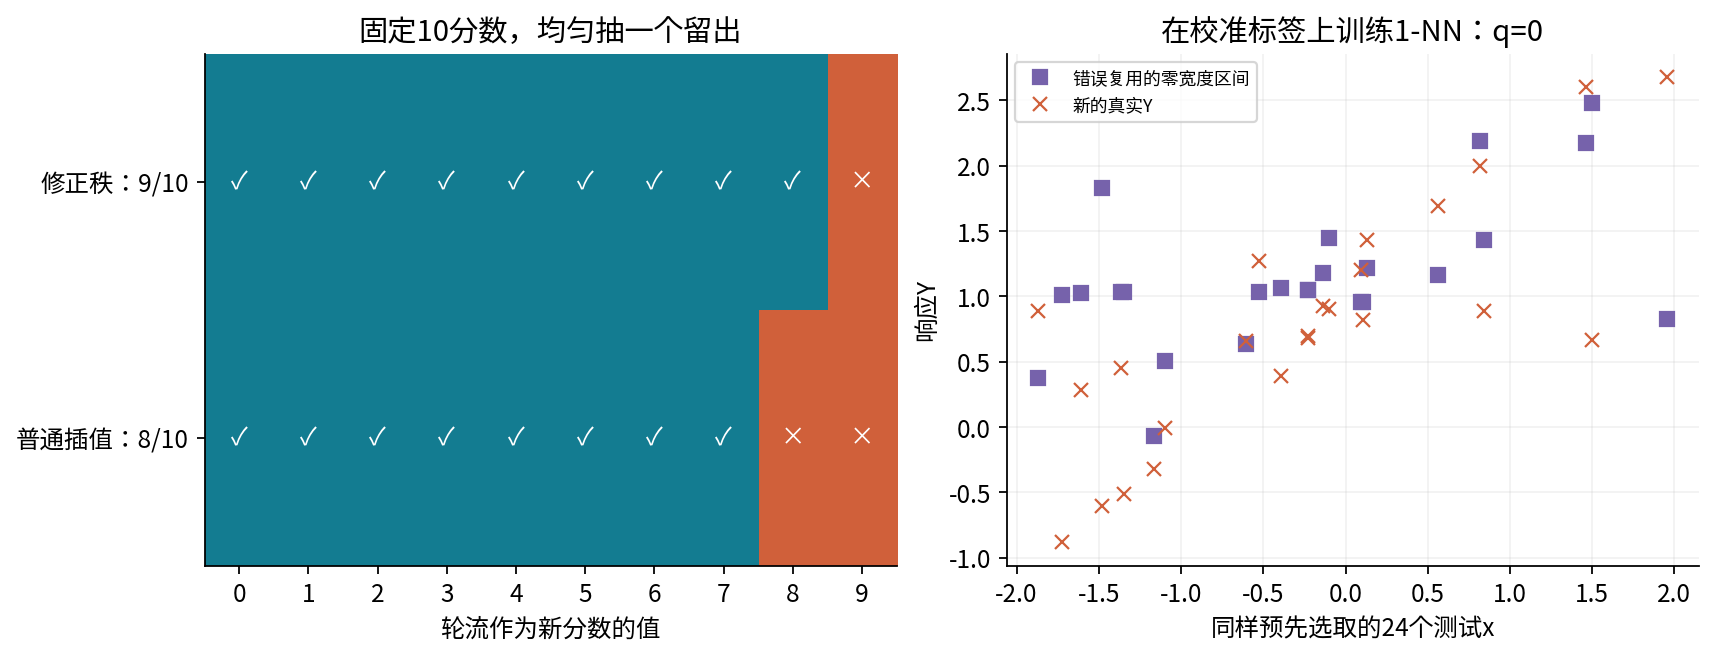

In [11]:
for alpha in cfg['miscoverage_boundary_examples']:
    print('Nine calibration scores:', cf.finite_sample_quantile(list(range(1,10)), alpha))
print('99 scores, alpha=.29:', cf.finite_sample_quantile(list(range(99)), .29))
print('Direct rank vs higher recipe:', cf.finite_sample_quantile(list(range(1,11)), .2)['quantile'],
      float(np.quantile(np.arange(1,11), .9, method='higher')))
print('Invalid reused 1NN quantile:', main['invalid_calibration_reuse']['quantile'])
print('Invalid reused 1NN coverage:', main['invalid_calibration_reuse']['evaluation']['coverage'])
show(10)

In [12]:
for z,y in [([1,2],[0,0]), ([0,0],[0,1]), ([1,2],[1,1])]:
    result = cb.fit_temperature(z,y)
    print('Boundary example:', z,y,result['status'],result['final']['inverse_temperature'],result['final']['temperature'])
infinite = cf.finite_sample_quantile([1,2], .1)
print('Infinite interval:', cf.interval_report([0,1], [100,-100], infinite))
for name, operation in [
    ('bool logit', lambda: cb.temperature_state([0, True], [0,1], 1)),
    ('invalid label', lambda: cb.temperature_state([0,1], [0,.5], 1)),
    ('rank deficient fit', lambda: cf.fit_line([1,1], [0,1])),
    ('negative score', lambda: cf.finite_sample_quantile([1,-1], .1))]:
    try: operation()
    except ValueError as ex: print('Expected rejection:', name, str(ex))
    else: raise RuntimeError('Invalid input accepted: '+name)

Boundary example: [1, 2] [0, 0] lower_boundary 0.0 None
Boundary example: [0, 0] [0, 1] lower_boundary 0.0 None
Boundary example: [1, 2] [1, 1] upper_boundary 4.0 0.25
Infinite interval: {'n': 2, 'coverage': 1.0, 'covered': [True, True], 'interval_lower': None, 'interval_upper': None, 'width': None, 'infinite_width': True, 'target': 'new observed response Y, not conditional mean'}
Expected rejection: bool logit logits requires a real scalar, not bool/string/complex
Expected rejection: invalid label labels must be 0/1
Expected rejection: rank deficient fit training line design is rank deficient
Expected rejection: negative score nonnegative calibration scores outside supported finite raw range


## 独立参照与可恢复科学结果
Decimal、标量OLS、实际SciPy/sklearn、秩枚举与定向泄漏检测并用。测试不能代替可交换性假设。

In [13]:
import audit
audit_result = audit.audit()
print(json.dumps(audit_result, ensure_ascii=False, sort_keys=True))
science_hash = hashlib.sha256(canonical_bytes(report)).hexdigest()
if science_hash != audit_result['core_sha256']:
    raise RuntimeError('Notebook main report differs from audited report')
safe_write(BASE / 'outputs/notebook-result.json', report)
print('Full report saved. Core SHA256:', science_hash)

{"core_sha256": "159d689b66383bfe5ece6cf734585382e57c4dd19efe382e8a7e77c325bbcbe2", "guards": {"all_protocol_fields_precompute_checked": true, "atomic_output_checked": true, "loaded_last_fields_precompute_checked": true, "rank_and_quantile_domain_checked": true}, "hand": {"Decimal_precision": 100, "distinct_ECE_definitions_checked": true, "finite_difference_best_errors": [2.6550872611608156e-11, 2.1428053775807143e-11, 1.617772582562793e-11], "full_hand_states": 3, "temperature_boundary_states_checked": true}, "rank": {"correct_coverage": "9/10", "higher_recipe_example": {"direct_kth": 9, "quantile_higher": 10}, "naive_interpolation_coverage": "8/10", "rank_cases": [{"alpha": 0.1, "infinite": false, "n": 9, "rank": 9}, {"alpha": 0.05, "infinite": true, "n": 9, "rank": 10}, {"alpha": 0.29, "infinite": false, "n": 9, "rank": 8}, {"alpha": 0.29, "infinite": false, "n": 99, "rank": 71}, {"alpha": 0.05, "infinite": false, "n": 19, "rank": 19}, {"alpha": 0.1, "infinite": true, "n": 1, "rank"